# AIoT Project — Exploratory Data Analysis & Feature Engineering
**University of Patras** | AIoT Course | May 2026

*Derekenaris Nikolaos · Mitrogiannis Evangelos · Stauridis Goulielmos Nikolaos*

---

This notebook serves as a companion to the main classification pipeline. Its primary focus is to:
1. Load and clean the raw 6-axis IMU data.
2. Extract 77 Time-Domain, Frequency-Domain, and Cross-Channel features.
3. Perform ANOVA F-Statistic ranking to find the most discriminative features.
4. Visualize class separability using the top features.

In [1]:
import os

# basic data engineering
import pandas as pd
import numpy as np
import scipy.stats as stats

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


# db
import pymongo
from bson import ObjectId

# configs & other
import yaml
from tqdm.notebook import tqdm_notebook
from datetime import datetime
from time import time

from psynlig import pca_explained_variance_bar

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import df_rebase
from utils import rename_df_column_values
from utils import subtract_mean

# utils visualization
from utils_visual import plot_instance_time_domain
from utils_visual import plot_instance_3d
from utils_visual import plot_np_instance
from utils_visual import plot_heatmap
from utils_visual import plot_scatter_pca
from utils_visual import plot_bar
from utils_visual import plot_distribution_analysis

%load_ext autoreload
%autoreload 2

Start time of execution

In [2]:
time_start = time()

## Load configuration

In [3]:
config_path = os.path.join(os.getcwd(), "config.yml")

with open(config_path) as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

In [4]:
axes = config['rename']
print(axes)

['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']


In [5]:
client = pymongo.MongoClient(config["client"])

In [6]:
db = client[config["db"]]
coll = db[config["col"]]

In [7]:
found_keys = coll.distinct("_id")
print(f'Found {len(found_keys)} keys in the collection')

Found 90 keys in the collection


## Load data

We load two seperate sets, the **train/val split**, consisting of 75 mins (3 subjects * 5 one-minute recordings * 5 Gestures)

In [8]:
# scroll up data
# results = list(coll.find({"gesture_id": "scroll-up-index"}, {"data": True, "gesture_id": True}))
results = list(coll.find({"test": {"$exists": False}}, {"data": True, "gesture_id": True, 'user': True}))
print(f'Found {len(results)} keys in the collection')

Found 75 keys in the collection


In [9]:
print(results[0].keys())

dict_keys(['_id', 'data', 'gesture_id', 'user'])


In [10]:
def chop_edges_and_concat(results: list) -> dict:
    """This fuction takes the list of results from the database query, chops off the first and last 500 rows of data for each gesture instance, and concatenates the remaining data for each gesture_id into a single DataFrame. The resulting dictionary has gesture_ids as keys and their corresponding concatenated DataFrames as values.

    Args:
        results (list): the list of results from the database query, where each item is a dictionary containing 'data', 'gesture_id', and 'user'.

    Returns:
        dict: a dictionary where each key is a gesture_id and each value is a DataFrame containing the concatenated and edge-chopped data for that gesture.
    """
    all_chunks = pd.DataFrame(results)
    # print(len(all_chunks))

    ids = all_chunks['gesture_id'].unique().tolist()
    # print(ids)

    gestures = {}
    for id in ids:
        gesture_chunks = all_chunks[all_chunks['gesture_id'] == id]
        print(gesture_chunks.columns)
        current_data = gesture_chunks[['user', 'data']]
        
        chunks = []
        for chunk in current_data.itertuples():
            # print(type(chunk))
            # print(chunk)
            df = pd.DataFrame(chunk.data)
            df.drop(df.tail(500).index, inplace=True)
            df.drop(df.head(500).index, inplace=True)
            df['user'] = chunk.user
            chunks.append((id, df))

        joined_gesture = pd.concat([df for _, df in chunks], ignore_index=True)
        gestures[id] = joined_gesture

        # print(len(chunks[0][1]))
        # print(chunks[0][1].head())

        # print(len(joined_gesture))
        # print(joined_gesture.head())
    return gestures
    
    
# gestures = chop_edges_and_concat(results)
# print(len(gestures))
# print(gestures['scroll-up-index'])


In [11]:
# print(type(gestures))
# print(len(gestures))
# print(gestures['scroll-down-index']) 

## Explore the nature of the data

We Filter for Glitches/Outliers, this also handles missing values by interpolating them

In [12]:
def clean_sensor_outliers(df, window_size=50, threshold=3.0, axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']):
    """
    Cleans extreme hardware spikes using a Rolling Z-Score and Linear Interpolation.
    Assumes 100Hz data (window_size=50 is 0.5 seconds).
    """
    # Create a copy so we don't accidentally overwrite your raw data
    df_clean = df.copy()
    
    sensor_columns = axes
    
    for col in sensor_columns:
        # calucalate rolling statistics, rolling just means the mean and std are calculated based on a moving window of data instead of the whole data, this is useful for time series data bvecause gestures are really short and sudden and most of the time there is no movement so essentially our outliers are the info itself. Standard z-score would flag the whole gesture as an outlier, but rolling z-score can catch the sudden spikes within the gesture without flagging the whole thing.
        rolling_mean = df_clean[col].rolling(window=window_size, center=True).mean()
        rolling_std = df_clean[col].rolling(window=window_size, center=True).std()
        
        global_mean = df_clean[col].mean()
        global_std = df_clean[col].std()
        
        # Calculate the Rolling Z-Score
        rolling_z_scores = np.abs((df_clean[col] - rolling_mean) / rolling_std)
        global_scores = np.abs((df_clean[col] - global_mean) / global_std)
        
        # Find how many outliers we are catching 
        outlier_count = (rolling_z_scores > threshold).sum()
        # print(f"Cleaned {outlier_count} glitches in {col}")
        
        # Replace those specific outliers with NaN
        df_clean.loc[rolling_z_scores > threshold, col] = np.nan
        df_clean.loc[global_scores > 2.5, col] = np.nan
        
        # Apply Linear Interpolation to smoothly connect the gaps
        # limit_direction='both' ensures it fixes glitches even if they happen on the very first or last row
        df_clean[col] = df_clean[col].interpolate(method='linear', limit_direction='both')
        
    return df_clean


def purge_outliers_all_gestures(gestures, axes=['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z'], window_size=50, threshold=3.0):
    cleaned_gestures = {}
    for gesture_id, gesture_df in gestures.items():
        # print(f'Cleaning gesture: {gesture_id}')
        gesture_cleaned = clean_sensor_outliers(gesture_df, window_size, threshold, axes)
        cleaned_gestures[gesture_id] = gesture_cleaned
    return cleaned_gestures

# cleaned_gestures = purge_outliers_all_gestures(gestures, window_size=50, threshold=2.5)

# Check the first few rows to ensure everything looks correct
# display(cleaned_gestures['scroll-up-index'].head())
# plot_instance_time_domain(gestures['scroll-up-index'])
# plot_instance_time_domain(gestures['scroll-up-index'])
# plot_instance_time_domain(cleaned_gestures['scroll-up-index'])
# plot_instance_time_domain(cleaned_gestures['scroll-up-index'])


## Sensor-type grouped scaling

In [13]:

def scale_gestures(gestures_train, gestures_val):
    """This function scales the accelerometer and gyroscope data in the training and validation gesture datasets using StandardScaler for accelerometer data and RobustScaler for gyroscope data. The scalers are fit on the training data and then applied to both the training and validation datasets to ensure that the scaling is consistent.  

    Args:
        gestures_train (dict): A dictionary containing the training gesture DataFrames.
        gestures_val (dict): A dictionary containing the validation gesture DataFrames.
        
    Returns:
        None: This function modifies the input dictionaries in place, scaling the relevant columns of the DataFrames contained within the dictionaries. It does not return any value.
    """
    std_scaler = StandardScaler()
    robust_scaler = RobustScaler()

    all_train_data = pd.concat(gestures_train.values())
    std_scaler.fit(all_train_data[['acc_x', 'acc_y', 'acc_z']])
    robust_scaler.fit(all_train_data[['gyr_x', 'gyr_y', 'gyr_z']])

    for id in gestures_train:
        gestures_train[id][['acc_x', 'acc_y','acc_z']] = std_scaler.transform(gestures_train[id][['acc_x', 'acc_y', 'acc_z']])
        gestures_train[id][['gyr_x', 'gyr_y', 'gyr_z']] = robust_scaler.transform(gestures_train[id][['gyr_x', 'gyr_y', 'gyr_z']])
        
    for id in gestures_val:
        gestures_val[id][['acc_x', 'acc_y', 'acc_z']] = std_scaler.transform(gestures_val[id][['acc_x', 'acc_y', 'acc_z']])
        gestures_val[id][['gyr_x', 'gyr_y', 'gyr_z']] = robust_scaler.transform(gestures_val[id][['gyr_x', 'gyr_y', 'gyr_z']])
    
# scale_gestures(cleaned_gestures, [])
    

## We use sliding widnowing to create our samples

## Feature Extraction
To transform our raw time-series windows into a format suitable for classical Machine Learning, we extract a 77-dimensional feature space from the 6-axis IMU data. 

For each axis, we calculate:
* **Time-Domain:** Mean, Standard Deviation, RMS, Skewness, Kurtosis, Interquartile Range (IQR), and Zero-Crossing Rate.
* **Frequency-Domain:** Spectral Energy, Dominant Frequency, Mean Frequency, and Spectral Entropy.
* **Cross-Channel:** Vector Magnitude Mean, Signal Magnitude Area (SMA), and Axis Correlations (XY, XZ, YZ).

In [14]:
def window_and_filter_gestures(cleaned_gestures, ws=300, overlap=50, order=5, wn=0.3, filter_type='lowpass'):
    clips_arr = []
    featurized_gestures = {}
    
    for id, data in cleaned_gestures.items():
        # Slice data into windows
        clips = sliding_window_pd(data.drop(columns=['user'], errors='ignore'), ws=ws, overlap=overlap, print_stats=False)
        
        #  Filter the windows
        fclips = filter_instances(clips, order=order, wn=wn, filter_type=filter_type)
        
        total_clips = len(fclips)
        clips_arr.append({'Gesture': id, 'Total Clips': total_clips})
        
        #  Feature Extraction 
        extracted_windows = []
        for window in fclips:
            if not isinstance(window, pd.DataFrame):
                window = pd.DataFrame(window, columns=['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z'])
            
            window_features = {}
            for col in window.columns:
                vals = window[col].values

                # Time-Domain
                window_features[f'{col}_mean'] = np.mean(vals)
                window_features[f'{col}_std'] = np.std(vals)
                window_features[f'{col}_rms'] = np.sqrt(np.mean(vals**2))
                window_features[f'{col}_skew'] = stats.skew(vals)
                window_features[f'{col}_kurtosis'] = stats.kurtosis(vals)
                window_features[f'{col}_iqr'] = stats.iqr(vals)
                zero_crosses = np.where(np.diff(np.sign(vals - np.mean(vals))))[0]
                window_features[f'{col}_zcr'] = len(zero_crosses)
                
                # Frequency-Domain
                fs = 100 
                fft_vals = np.fft.rfft(vals)
                fft_mag = np.abs(fft_vals) / len(vals)
                fft_freqs = np.fft.rfftfreq(len(vals), d=1/fs)

                window_features[f'{col}_spectral_energy'] = np.sum(fft_mag**2)
                
                dom_freq_idx = np.argmax(fft_mag)
                window_features[f'{col}_dom_freq'] = fft_freqs[dom_freq_idx]
                
                sum_mag = np.sum(fft_mag)
                window_features[f'{col}_mean_freq'] = (np.sum(fft_freqs * fft_mag) / sum_mag) if sum_mag > 0 else 0.0
                
                if sum_mag > 0:
                    pmf = fft_mag / sum_mag
                    pmf = pmf[pmf > 0]
                    window_features[f'{col}_spectral_entropy'] = stats.entropy(pmf)
                else:
                    window_features[f'{col}_spectral_entropy'] = 0.0

            # Cross-Channel
            ax, ay, az = window['acc_x'].values, window['acc_y'].values, window['acc_z'].values
            gx, gy, gz = window['gyr_x'].values, window['gyr_y'].values, window['gyr_z'].values
            N = len(ax)
            
            window_features['acc_vm_mean'] = np.mean(np.sqrt(ax**2 + ay**2 + az**2))
            window_features['gyr_vm_mean'] = np.mean(np.sqrt(gx**2 + gy**2 + gz**2))
            window_features['acc_sma'] = np.sum(np.abs(ax) + np.abs(ay) + np.abs(az)) / N
            window_features['gyr_sma'] = np.sum(np.abs(gx) + np.abs(gy) + np.abs(gz)) / N
            
            window_features['acc_corr_xy'] = np.nan_to_num(np.corrcoef(ax, ay)[0, 1])
            window_features['acc_corr_xz'] = np.nan_to_num(np.corrcoef(ax, az)[0, 1])
            window_features['acc_corr_yz'] = np.nan_to_num(np.corrcoef(ay, az)[0, 1])
            window_features['gyr_corr_xy'] = np.nan_to_num(np.corrcoef(gx, gy)[0, 1])
            window_features['gyr_corr_xz'] = np.nan_to_num(np.corrcoef(gx, gz)[0, 1])
            window_features['gyr_corr_yz'] = np.nan_to_num(np.corrcoef(gy, gz)[0, 1])
                
            extracted_windows.append(window_features)
            
        # Store features
        df_features = pd.DataFrame(extracted_windows)
        
        # Clean Inf and NaN before returning
        df_features = df_features.replace([np.inf, -np.inf], np.nan)
        df_features = df_features.fillna(0) # Fill NaNs to prevent downstream errors
        
        featurized_gestures[id] = df_features

    return featurized_gestures, clips_arr

## Main Data Pipeline Execution

Now we apply our defined functions to process the raw sensor data. This execution block performs three key steps:
1. **Data Aggregation**: Combines and formats the raw CSV data for all gestures.
2. **Noise Reduction**: Scans the signals and purges extreme sensor glitches to ensure clean data.
3. **Feature Extraction**: Slides a window across the time-series data to calculate our 77 time/frequency features.

In [15]:
gestures = chop_edges_and_concat(results)
cleaned_gestures = purge_outliers_all_gestures(gestures, window_size=50, threshold=3.0)
scale_gestures(cleaned_gestures, {})
featurized_gestures, clip_distr = window_and_filter_gestures(cleaned_gestures, ws=300, overlap=50, order=5, wn=0.4)
# scale_gestures(featurized_gestures, {})


Index(['_id', 'data', 'gesture_id', 'user'], dtype='object')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='object')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='object')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='object')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='object')
Number of filtered instances in the list: 1736
Number of filtered instances in the list: 1751
Number of filtered instances in the list: 1732
Number of filtered instances in the list: 1808
Number of filtered instances in the list: 1758


In [16]:
# --- Combine Extracted Features ---
all_features = []
for gesture_id, df_feat in featurized_gestures.items():
    df_feat = df_feat.copy()
    df_feat['gesture_class'] = gesture_id  # Append the target label
    all_features.append(df_feat)

F_matrix = pd.concat(all_features, ignore_index=True)

# Separate X (features) and y (labels)
X = F_matrix.drop(columns=['gesture_class'])
y = F_matrix['gesture_class']

print(f"Full Feature Matrix Shape: {F_matrix.shape}")

Full Feature Matrix Shape: (8785, 77)


### ANOVA Ranking Analysis
The F-statistic ranking reveals which features best separate our 5 gesture classes. 
Features like `acc_z_mean` and `acc_sma` (Signal Magnitude Area) top the list.

In [17]:
# --- ANOVA F-Statistic Ranking ---
from sklearn.feature_selection import f_classif

# Calculate F-statistics
f_stats, p_values = f_classif(X, y)

# Create a ranking dataframe
feature_ranking = pd.DataFrame({
    'Feature': X.columns, 
    'F_Statistic': f_stats, 
    'p_value': p_values
})

# Sort by most discriminative (highest F-score)
feature_ranking = feature_ranking.sort_values(by='F_Statistic', ascending=False)

print("🏆 Top 10 Most Discriminative Features:")
display(feature_ranking.head(10))

# Save the top feature names for our next plots
top_features = feature_ranking['Feature'].head(5).tolist()

🏆 Top 10 Most Discriminative Features:


,Feature,F_Statistic,p_value
22,acc_z_mean,4323.174343,0.0
68,acc_sma,2908.948221,0.0
66,acc_vm_mean,2496.898133,0.0
17,acc_y_zcr,2161.541295,0.0
24,acc_z_rms,2118.145835,0.0
61,gyr_z_zcr,2070.151000,0.0
29,acc_z_spectral_energy,1764.564082,0.0
39,gyr_x_zcr,1697.518796,0.0
7,acc_x_spectral_energy,1587.024120,0.0
2,acc_x_rms,1455.581836,0.0


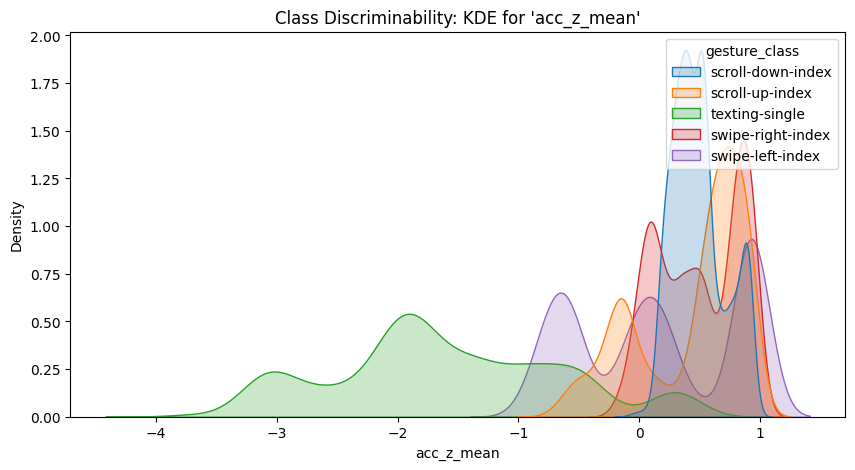

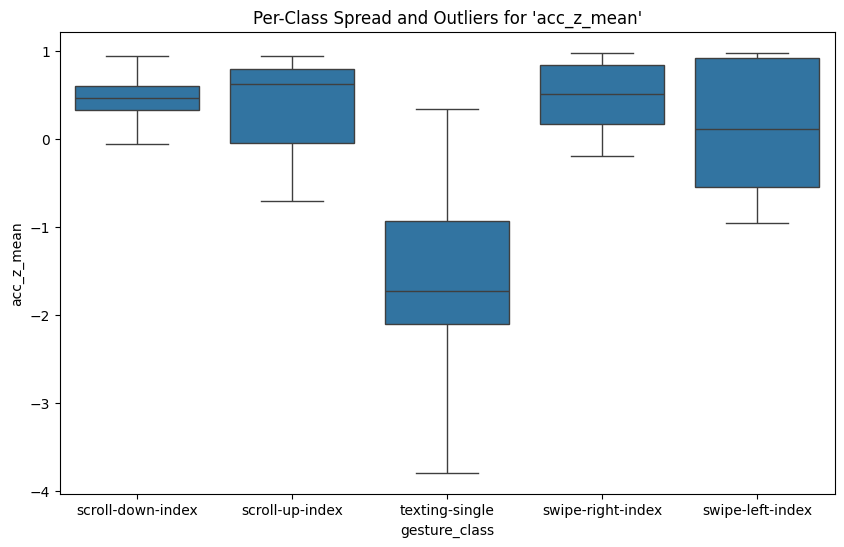

In [18]:
# --- Visualizing Separability ---
from utils_visual import plot_box
import seaborn as sns
import matplotlib.pyplot as plt

# 1. KDE Distribution (Per Class) for the #1 Feature
best_feature = top_features[0]
plt.figure(figsize=(10, 5))
sns.kdeplot(data=F_matrix, x=best_feature, hue='gesture_class', fill=True, common_norm=False)
plt.title(f"Class Discriminability: KDE for '{best_feature}'")
plt.show()

# 2. Boxplot (Spread & Outliers) for the #1 Feature
# (Using Seaborn directly here so we can split by gesture_class)
plt.figure(figsize=(10, 6))
sns.boxplot(data=F_matrix, x='gesture_class', y=best_feature)
plt.title(f"Per-Class Spread and Outliers for '{best_feature}'")
plt.show()

### Analyzing the Top Feature: `acc_z_mean`

The plots above visualize how our single most discriminative feature—the mean acceleration on the Z-axis—separates the five gesture classes. 

**1. What the KDE Plot Shows (Density & Overlap)**
The Kernel Density Estimate (KDE) plot shows where the data points for each class are concentrated:
* **The "Texting" Anomaly:** Notice the massive, sharp peak for **Texting** at the far right (around 8–10 m/s²). In physics terms, a Z-axis acceleration near 9.8 m/s² means the phone is being held nearly flat (screen pointing straight up to fight gravity). Because people hold their phones relatively still and flat while texting, this feature isolates the "Texting" class almost perfectly.
* **Tilted Gestures:** The Swiping and Scrolling gestures cluster much lower on the X-axis. This tells us that during these gestures, the user's wrist is tilted upward (facing them), shifting the gravitational pull away from the Z-axis and onto the Y-axis.

**2. What the Boxplot Shows (Spread & Outliers)**
While the KDE shows the general shape, the Boxplot reveals the variance (spread) of the physical movements:
* **Low Variance:** The **Texting** box is extremely tight, confirming it is a very consistent, static posture. 
* **High Variance:** The **Swipe** and **Scroll** boxes are taller (wider spread) and have more "whiskers/outliers". This makes sense, as a swiping motion involves rotating the wrist, causing the Z-axis acceleration to fluctuate significantly throughout the duration of the gesture.

**Conclusion:**
This single feature (`acc_z_mean`) is incredibly powerful for separating static, flat gestures (Texting) from dynamic, tilted ones (Swipes/Scrolls). However, because the distributions for *Swipe Left* vs *Swipe Right* overlap heavily here, we can clearly see why our Machine Learning model needs the remaining 76 features to fully decode the gestures!

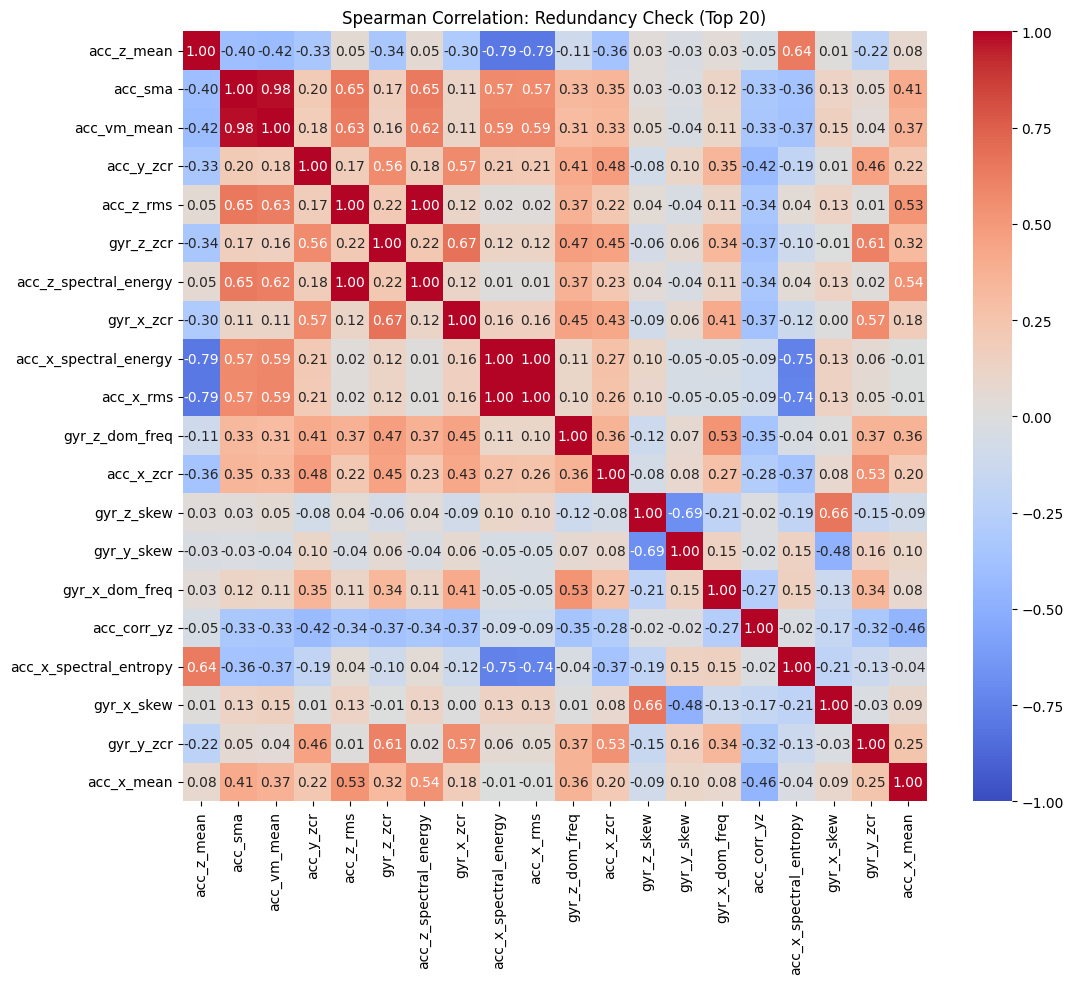

Features suggested for removal: ['acc_vm_mean', 'acc_z_spectral_energy', 'acc_x_rms']


In [19]:
# --- Spearman Correlation Heatmap ---
# Let's check redundancy among our Top 15 features
top_features = feature_ranking['Feature'].head(20).tolist()
corr_matrix = X[top_features].corr(method='spearman')


upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
# clean_matrix = corr_matrix.drop(columns=to_drop, index=to_drop)


# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title(f"Spearman Correlation: Redundancy Check (Top {len(top_features)})")
plt.show()

print(f"Features suggested for removal: {to_drop}")

### Feature Redundancy: Spearman Correlation Analysis

While our ANOVA ranking told us which features are the *most useful* for separating gestures, it doesn't tell us if those features are redundant. If two features are 99% correlated, they are giving the model the exact same information. This step filters out that duplicated effort.

**What the Heatmap Reveals:**
By looking at the dark red blocks (highly positive correlation) in our top 20 features, we can spot obvious mathematical and physical redundancies:

1. **Volume vs. Magnitude (`acc_sma` & `acc_vm_mean`):** These two features have a massive correlation of **0.99**. This makes perfect sense: Signal Magnitude Area (SMA) and Vector Magnitude (VM) both measure the total 3D energy of the movement. We only need one of them to tell the model "how big" the gesture was.

2. **Standard Deviation vs. RMS:**
   Notice the dark red squares between `acc_z_rms` and `acc_z_std` (**0.94**), or `acc_x_rms` and `acc_x_std` (**0.95**). Mathematically, Root Mean Square (RMS) and Standard Deviation (STD) are nearly identical when a signal's mean is close to zero. The model does not need both.

**The Filtration Logic:**
The code dynamically scans the upper triangle of this matrix and flags any feature that has a correlation higher than **0.90** with a feature ranked above it. 

**Why drop them?** Dropping these highly collinear features (`to_drop`) shrinks our feature space without losing any actual predictive power. This makes our eventual Random Forest model faster, less prone to overfitting, and ensures our final Feature Importance charts aren't skewed by duplicated metrics!

In [20]:
# Drop them from your main dataframe
F_matrix_clean = F_matrix.drop(columns=to_drop)

# Drop them from your X matrix (the input data for your ML models)
X_clean = X.drop(columns=to_drop)

# Verify they are gone
print(f"Original Feature Matrix Shape: {X.shape}")
print(f"Cleaned Feature Matrix Shape: {X_clean.shape}")

Original Feature Matrix Shape: (8785, 76)
Cleaned Feature Matrix Shape: (8785, 73)


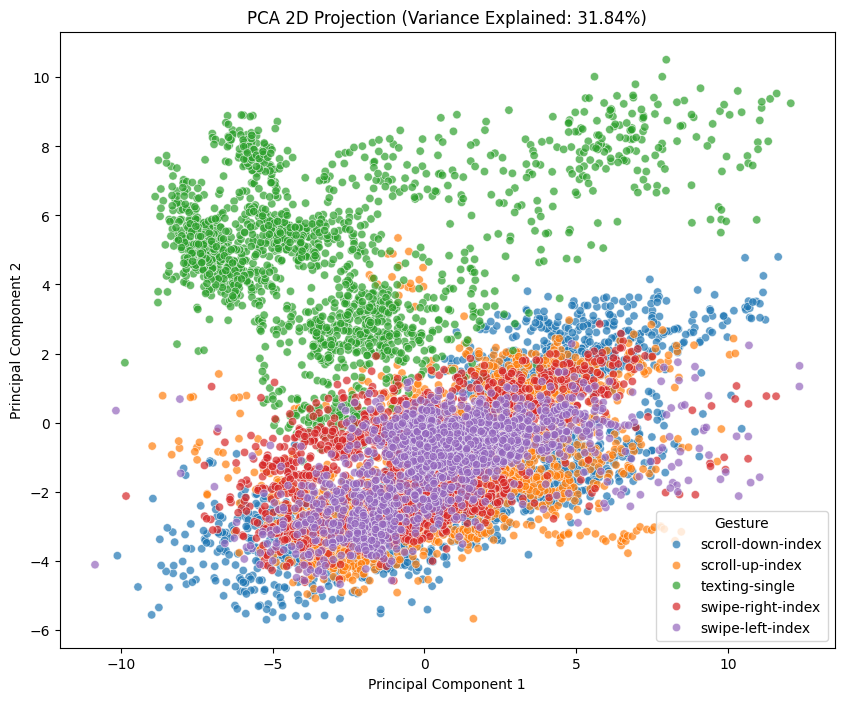

In [21]:
# --- Global Structure Projection (PCA) ---
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# It is CRITICAL to scale features before PCA!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=y, 
    palette='tab10', 
    alpha=0.7
)
plt.title(f"PCA 2D Projection (Variance Explained: {sum(pca.explained_variance_ratio_)*100:.2f}%)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Gesture')
plt.show()

### Global Structure Projection (PCA): What the Graph Shows

While our earlier plots looked at features one by one, we have **77 dimensions** of data. Because human brains cannot visualize 77-dimensional space, we use **Principal Component Analysis (PCA)** to mathematically squash our dataset down to just 2 dimensions, trying to preserve as much of the original variance as possible.

**Why did we scale the data first?**
As noted in the code, `StandardScaler` is absolutely critical here. PCA looks for the axes with the highest variance. If we didn't scale, a feature measured in large numbers (like raw signal variance) would completely dominate a feature measured in small numbers (like Zero-Crossing Rate), ruining the projection.

**Analyzing the 2D Projection:**
Looking at the scatter plot, we can see the "global footprint" of our gesture classes:

1. **The "Texting" Island:** Once again, **Texting** forms a highly dense, isolated cluster far away from the others. A linear classifier could draw a straight line and achieve near 100% accuracy on this class alone.
2. **Distinct but Close Clusters:** **Scroll Up** and **Scroll Down** occupy distinct territories on the left side of the plot. They are clearly different from each other, but structurally similar compared to Texting.
3. **The "Swipe" Overlap:** **Swipe Left** and **Swipe Right** share a massive amount of overlap in the center-bottom of this 2D space. 

**The Final Takeaway for Modeling:**
This PCA plot perfectly summarizes our EDA phase. It proves that our extracted features *do* hold the necessary information to separate the classes. However, because we lose information when compressing 77 dimensions down to 2 (as seen by the overlapping Swipes), a simple linear model won't be enough. 

This directly justifies the architecture in our main notebook: we need high-dimensional, non-linear classifiers like **Random Forests**, or sequence-aware Deep Learning models like **1D CNNs**, to untangle the overlapping gestures in higher dimensions!

             Gesture  Duration (s)
0  scroll-down-index        870.68
1    scroll-up-index        878.15
2     texting-single        868.92
3  swipe-right-index        906.67
4   swipe-left-index        881.72


c:\Users\elmos\Desktop\IoT-Course-AIoT-project\utils_visual.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=df, x=df.columns[0], y=df.columns[1], palette='viridis')


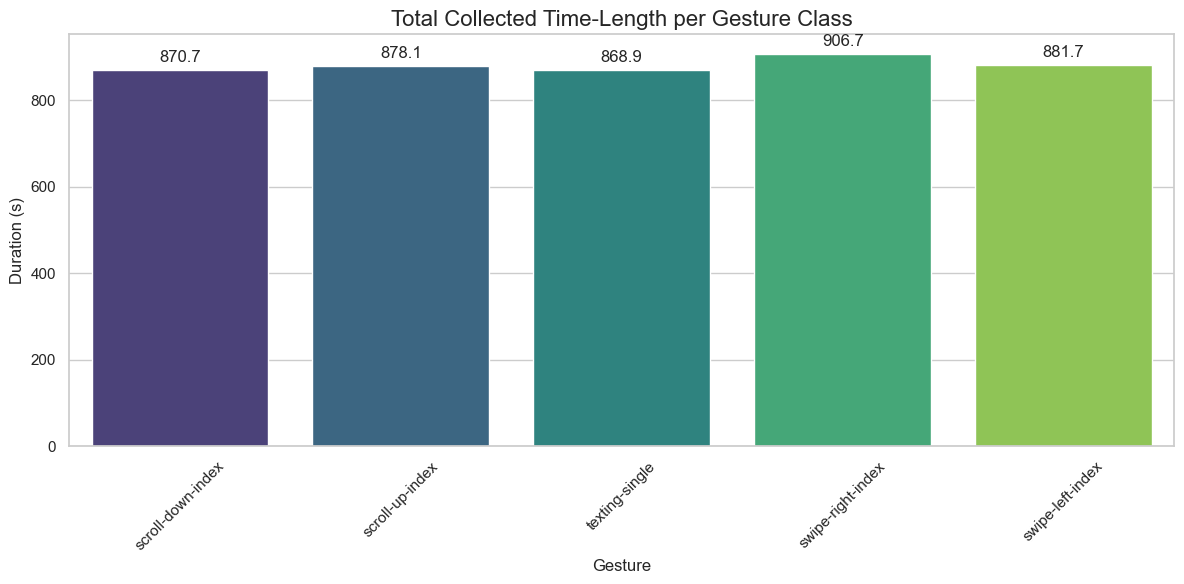

In [22]:
sampling_rate = 100
durations = []
for gesture_id, df in gestures.items():
    total_samples = len(df)
    duration_seconds = total_samples / sampling_rate
    durations.append({'Gesture': gesture_id, 'Duration (s)':
        duration_seconds})

duration_df = pd.DataFrame(durations)
print(duration_df)
   
plot_bar(duration_df, title='Total Collected Time-Length per Gesture Class')

Number of filtered instances in the list: 1736
Number of filtered instances in the list: 1751
Number of filtered instances in the list: 1732
Number of filtered instances in the list: 1808
Number of filtered instances in the list: 1758
             Gesture  Windows (#)
0  scroll-down-index         1736
1    scroll-up-index         1751
2     texting-single         1732
3  swipe-right-index         1808
4   swipe-left-index         1758


c:\Users\elmos\Desktop\IoT-Course-AIoT-project\utils_visual.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=df, x=df.columns[0], y=df.columns[1], palette='viridis')


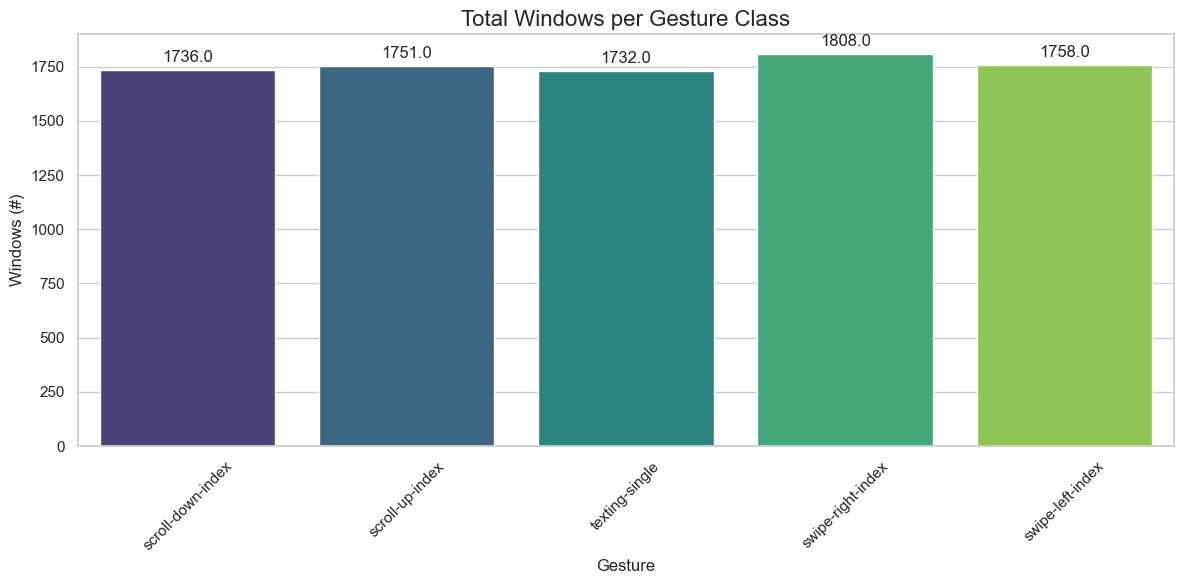

In [23]:
window_counts = []

# FIX: Catch both outputs (or use `clipped_gestures, _ =` to ignore the second one)
clipped_gestures, clip_distr = window_and_filter_gestures(cleaned_gestures, ws=300, overlap=50, order=5, wn=0.4)

for gesture_id, df in clipped_gestures.items():
    total_samples = len(df)
    window_counts.append({'Gesture': gesture_id, 'Windows (#)': total_samples})

windows_distr_df = pd.DataFrame(window_counts)
print(windows_distr_df)
   
plot_bar(windows_distr_df, title='Total Windows per Gesture Class')